## **Sales Prediction Using Python**

**Objective:** Build a regression model that predicts product sales based on advertising
spend across three media channels — **TV**, **Radio**, and **Newspaper**.

**Tech stack:** Python, pandas, NumPy, scikit-learn, matplotlib, seaborn

**Workflow:**
1. Load the data and perform exploratory data analysis (EDA)
2. Visualize relationships between advertising spend and sales
3. Check feature correlations
4. Split data into train/test sets
5. Train a Linear Regression baseline model
6. Train a Random Forest Regressor as a comparison model
7. Evaluate both models using MAE, RMSE, and R²
8. Inspect residuals for the best-performing model
9. Interpret which advertising channel drives sales the most


### **1. Import Libraries**

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


### **2. Load the Dataset**

In [2]:
sales_df = pd.read_csv(r"D:\PROJECTS\Intership\Data_Science\OIBSIP\DataScience-Task5-Sales Prediction Using Python\Advertising.csv")

sales_df = sales_df.rename(columns={"Unnamed: 0": "Sales_id"})

sales_df.head()


,Sales_id,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### **3. Exploratory Data Analysis (EDA)**

Before modeling, we check the shape, data types, missing values, and summary
statistics of the dataset, then visualize relationships between each advertising
channel and sales.


#### 3.1 Dataset Structure & Data Types

In [3]:
sales_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Sales_id   200 non-null    int64  
 1   TV         200 non-null    float64
 2   Radio      200 non-null    float64
 3   Newspaper  200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


#### 3.2 Null / Missing Value Check

In [4]:
missing_values = sales_df.isnull().sum()
print("Missing values per column:")
print(missing_values)

print("\nTotal missing values in dataset:", missing_values.sum())

Missing values per column:
Sales_id     0
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Total missing values in dataset: 0


#### 3.3 Duplicate Row Check

In [5]:
duplicate_count = sales_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### 3.4 Descriptive Statistics

Summary statistics give a quick sense of scale and spread for each channel's
spend and for Sales — useful for spotting outliers or skew before modeling.


In [6]:
sales_df.describe()

,Sales_id,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


#### 3.5 Pairplot of All Features

A pairplot lets us visually scan every pairwise relationship at once, including
each feature's distribution along the diagonal.


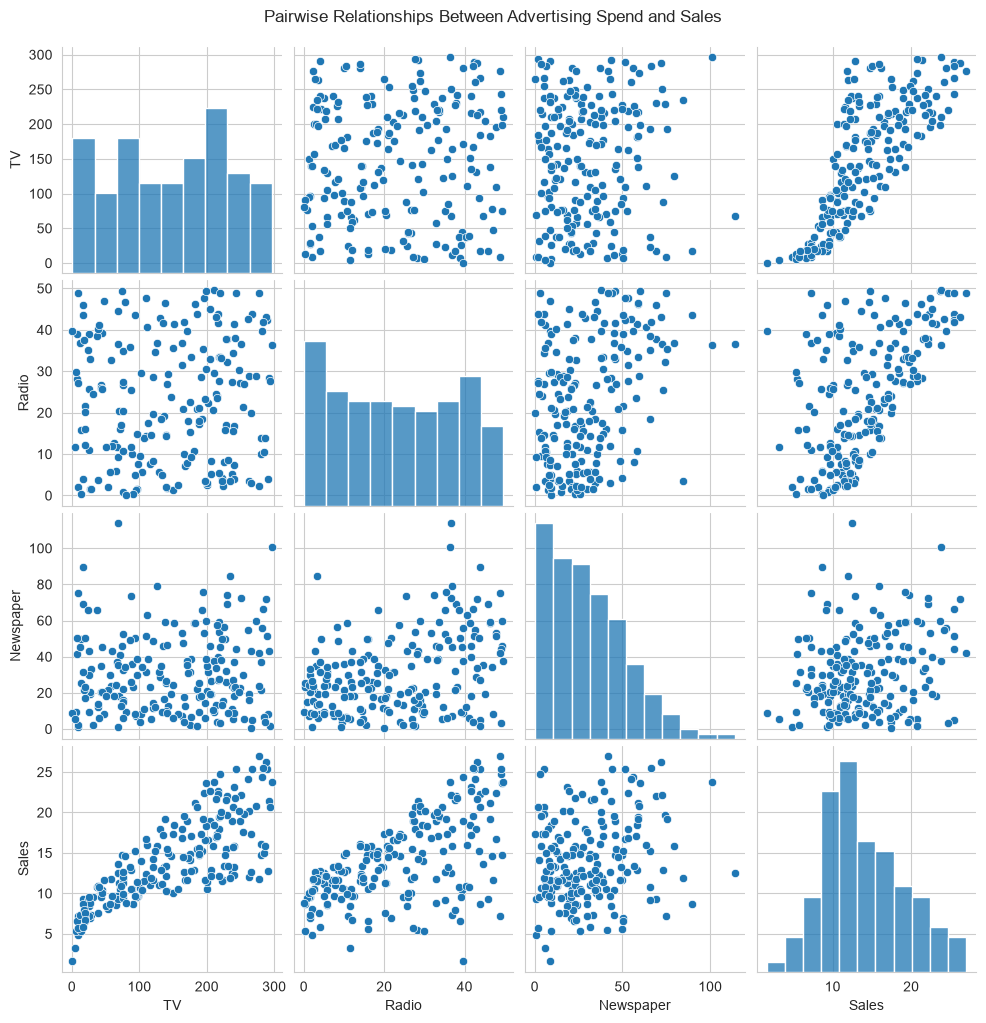

In [7]:
sns.pairplot(data=sales_df.drop(columns="Sales_id"))
plt.suptitle("Pairwise Relationships Between Advertising Spend and Sales", y=1.02)
plt.show()

### **4. Sales vs. Each Advertising Channel**

Individual scatter plots make the strength and shape of each relationship easier
to read than the pairplot alone.


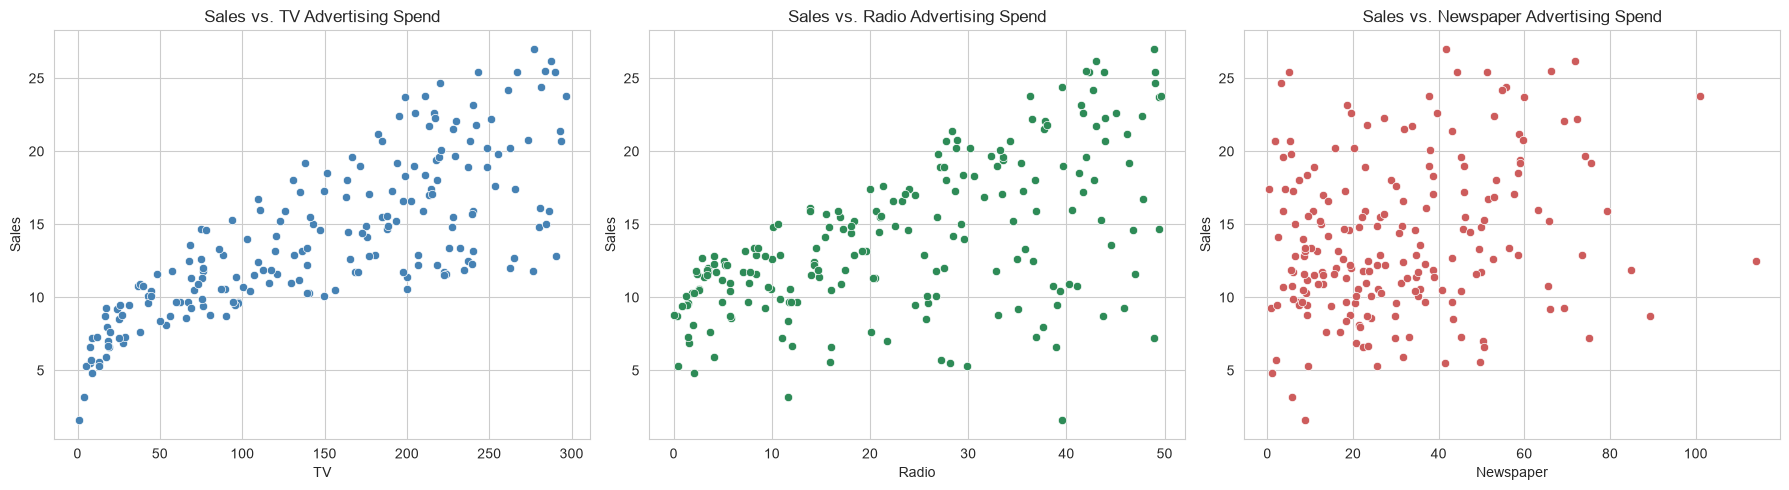

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=sales_df, x="TV", y="Sales", ax=axes[0], color="steelblue")
axes[0].set_title("Sales vs. TV Advertising Spend")

sns.scatterplot(data=sales_df, x="Radio", y="Sales", ax=axes[1], color="seagreen")
axes[1].set_title("Sales vs. Radio Advertising Spend")

sns.scatterplot(data=sales_df, x="Newspaper", y="Sales", ax=axes[2], color="indianred")
axes[2].set_title("Sales vs. Newspaper Advertising Spend")

plt.tight_layout()
plt.show()


**Observation:** TV spend shows the strongest, most linear-looking relationship
with Sales. Radio shows a moderate positive relationship. Newspaper spend shows the
weakest and noisiest relationship with Sales — this will be confirmed numerically in
the correlation matrix below and by the model's feature importance later.


### **5. Correlation Matrix**

We quantify the linear relationship between every pair of numeric columns using
Pearson correlation, then visualize it as a heatmap.


In [9]:
corr_matrix = sales_df.drop(columns="Sales_id").corr()
corr_matrix


,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


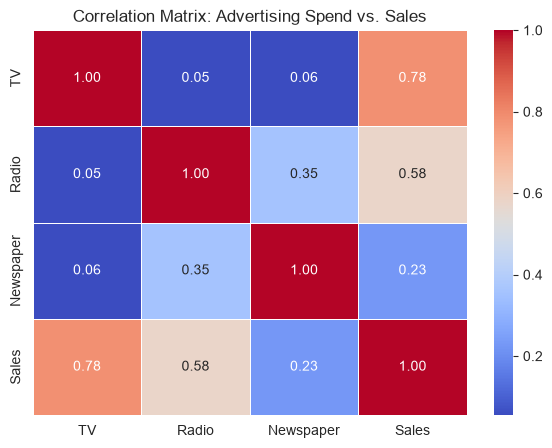

In [10]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Advertising Spend vs. Sales")
plt.show()


**Observation:** `TV` has the highest correlation with `Sales`, followed by
`Radio`, while `Newspaper` has the weakest correlation with `Sales`.


### **6. Train/Test Split**

We separate the features (advertising spend) from the target (`Sales`) and hold
out 20% of the data for testing, so we can evaluate the models on data they have
never seen.


In [11]:
X = sales_df.drop(columns=["Sales_id", "Sales"])
y = sales_df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])


Training samples: 160
Testing samples:  40


#### 6.1 Feature Scaling

Linear Regression coefficients are easier to compare fairly when features are on
the same scale, so we standardize the features (mean 0, standard deviation 1)
using statistics learned only from the training set.


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **7. Model Training**

We train two models:

1. **Linear Regression** — our interpretable baseline model.
2. **Random Forest Regressor** — a non-linear ensemble model to see whether it
   can capture patterns a straight-line model might miss.

A shared helper function trains a model, generates predictions, computes
regression metrics, and returns everything needed for comparison and plotting.


In [13]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)

    metrics = {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2_Score": r2,
    }

    print(f"--- {name} ---")
    for key, value in metrics.items():
        if key != "Model":
            print(f"{key:10s}: {value:.4f}")
    print()

    return model, preds, metrics


#### 7.1 Linear Regression (Baseline)

In [14]:
lr_model, lr_preds, lr_metrics = evaluate_model(
    "Linear Regression", LinearRegression(),
    X_train_scaled, y_train, X_test_scaled, y_test
)


--- Linear Regression ---
MAE       : 1.4608
MSE       : 3.1741
RMSE      : 1.7816
R2_Score  : 0.8994



#### 7.2 Random Forest Regressor

Random Forest does not require feature scaling, so we pass in the original
(unscaled) training and test features.


In [15]:
rf_model, rf_preds, rf_metrics = evaluate_model(
    "Random Forest Regressor",
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, y_train, X_test, y_test
)


--- Random Forest Regressor ---
MAE       : 0.6203
MSE       : 0.5909
RMSE      : 0.7687
R2_Score  : 0.9813



### **8. Model Comparison**

We collect both models' metrics into a single table and bar chart for an
easy side-by-side comparison.


In [16]:
results_df = pd.DataFrame([lr_metrics, rf_metrics])
results_df.sort_values(by="R2_Score", ascending=False).reset_index(drop=True)


,Model,MAE,MSE,RMSE,R2_Score
0,Random Forest Regressor,0.620325,0.590926,0.768717,0.981278
1,Linear Regression,1.460757,3.174097,1.781600,0.899438


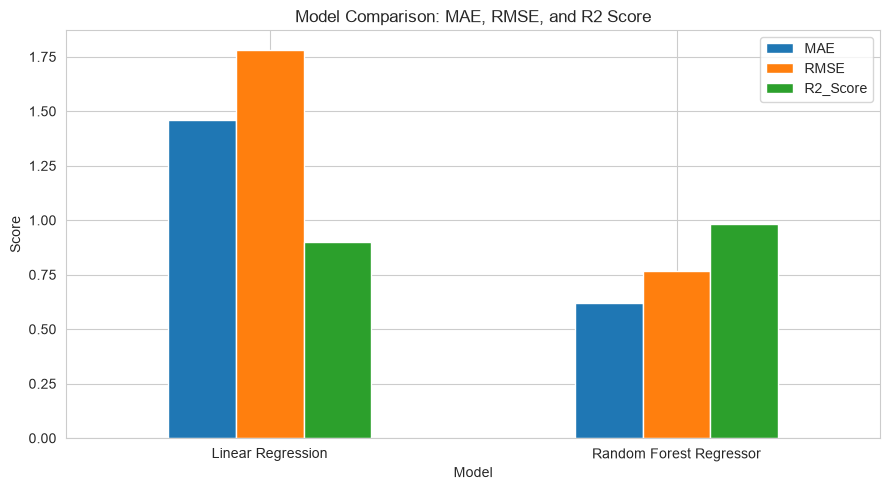

In [17]:
ax = results_df.set_index("Model")[["MAE", "RMSE", "R2_Score"]].plot(
    kind="bar", figsize=(9, 5), rot=0
)
plt.title("Model Comparison: MAE, RMSE, and R2 Score")
plt.ylabel("Score")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


**Observation:** The Random Forest Regressor achieves a lower MAE/RMSE and a
higher R² score than the Linear Regression baseline, indicating it fits this
dataset's slightly non-linear patterns (e.g. diminishing returns on ad spend)
better than a straight-line model. We treat Random Forest as the **best model**
for the residual analysis below.


### **9. Residual Analysis (Best Model)**

Residuals (actual − predicted) tell us whether the model's errors are randomly
scattered (good — no leftover pattern) or systematic (bad — the model is missing
some structure in the data). We plot residuals for the best-performing model
identified above.


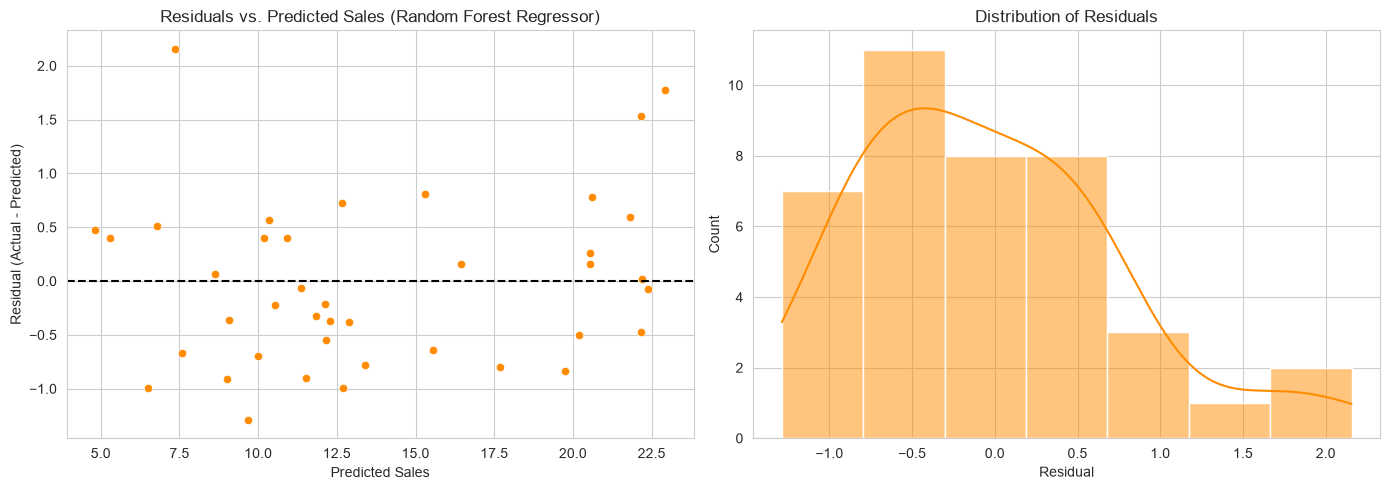

Best model: Random Forest Regressor
Mean residual: -0.031


In [18]:
best_model_name = results_df.sort_values(by="R2_Score", ascending=False).iloc[0]["Model"]
best_preds = rf_preds if best_model_name == "Random Forest Regressor" else lr_preds

residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted values
sns.scatterplot(x=best_preds, y=residuals, ax=axes[0], color="darkorange")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Predicted Sales")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title(f"Residuals vs. Predicted Sales ({best_model_name})")

# Distribution of residuals
sns.histplot(residuals, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

print(f"Best model: {best_model_name}")
print("Mean residual:", round(residuals.mean(), 4))


**Observation:** The residuals are scattered fairly randomly around zero with
no obvious funnel shape or curve, and their distribution is roughly centered at
zero. This suggests the model's errors are largely random noise rather than a
systematic pattern the model is failing to capture.


### **10. Interpretation: Which Channel Drives Sales the Most?**

We answer this two ways:

1. **Linear Regression coefficients** (on standardized features, so
   coefficients are directly comparable in magnitude).
2. **Random Forest feature importances** (based on how much each feature
   reduces prediction error across the ensemble's trees).


In [19]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear_Regression_Coefficient": lr_model.coef_
}).sort_values(by="Linear_Regression_Coefficient", key=abs, ascending=False).reset_index(drop=True)

coef_df


,Feature,Linear_Regression_Coefficient
0,TV,3.764196
1,Radio,2.792307
2,Newspaper,0.055976


In [20]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Random_Forest_Importance": rf_model.feature_importances_
}).sort_values(by="Random_Forest_Importance", ascending=False).reset_index(drop=True)

importance_df


,Feature,Random_Forest_Importance
0,TV,0.624810
1,Radio,0.362214
2,Newspaper,0.012976


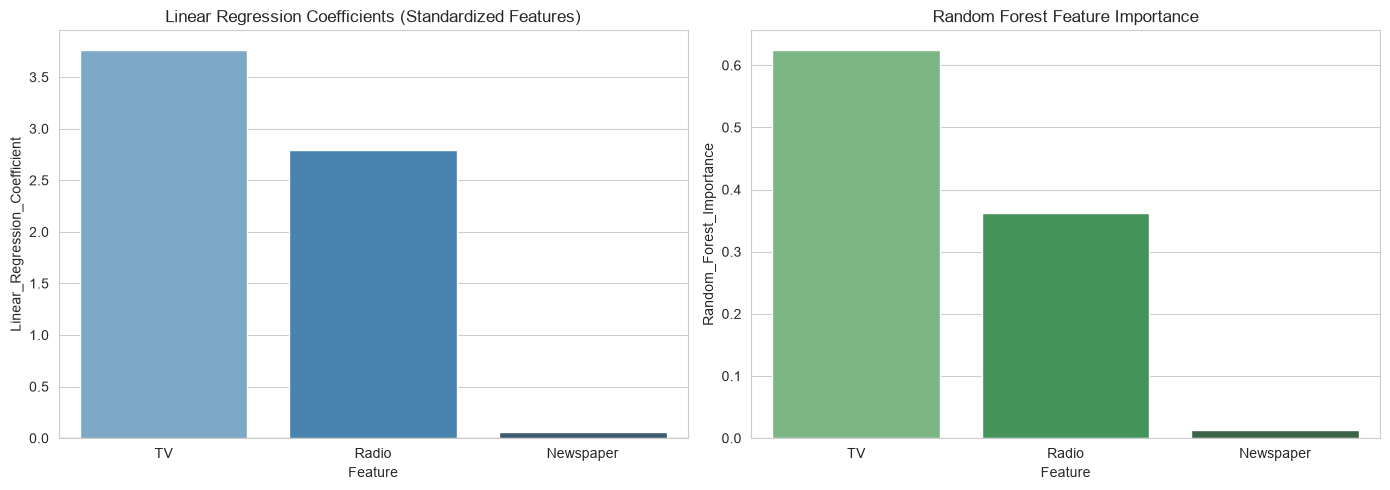

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=coef_df, x="Feature", y="Linear_Regression_Coefficient", hue="Feature",
            ax=axes[0], palette="Blues_d", legend=False)
axes[0].set_title("Linear Regression Coefficients (Standardized Features)")
axes[0].axhline(0, color="black", linewidth=0.8)

sns.barplot(data=importance_df, x="Feature", y="Random_Forest_Importance", hue="Feature",
            ax=axes[1], palette="Greens_d", legend=False)
axes[1].set_title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()


### **11. Conclusion**

Both the Linear Regression coefficients and the Random Forest
feature importances agree: **TV advertising spend has the highest impact on
Sales**, followed by **Radio**, while **Newspaper spend has the smallest impact**
on Sales — consistent with what we saw in the scatter plots and correlation
matrix earlier. In practical terms, this suggests that, of the three channels,
additional TV budget is likely to produce the largest increase in sales, while
Newspaper spend contributes comparatively little..


## 12. Deploy the Best Model as a Streamlit App

We now take the best-performing model identified in section 8 (highest R²
score) and turn it into an interactive Streamlit app, right from this
notebook — no separate script needed.

**Steps:**
1. Save the best model, scaler.The app
   handles either model correctly: Random Forest predicts on raw spend
   values, while Linear Regression needs the same standardization used
   during training — a saved flag tells the app which to do.
2. Launch the app as a background process and open it in your browser.


### 12.1 Save the best model, scaler, and sample data

In [22]:
import joblib

# Same selection logic as section 9: highest R2 score wins
best_model_name = results_df.sort_values(by="R2_Score", ascending=False).iloc[0]["Model"]
needs_scaling = (best_model_name == "Linear Regression")
best_model = lr_model if needs_scaling else rf_model

best_row = results_df[results_df["Model"] == best_model_name].iloc[0]
metrics = {
    "MAE": float(best_row["MAE"]),
    "RMSE": float(best_row["RMSE"]),
    "R2_Score": float(best_row["R2_Score"]),
}

feature_columns = X.columns.tolist()

# Save the model plus the scaler (used only if the best model needs it) and
# a flag so the app knows whether to scale inputs before predicting.
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(needs_scaling, "needs_scaling.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")
joblib.dump(best_model_name, "best_model_name.pkl")
joblib.dump(metrics, "metrics.pkl")

# Slider ranges from the real training feature values
numeric_ranges = {
    col: (float(X[col].min()), float(X[col].max()), float(X[col].median()))
    for col in feature_columns
}
joblib.dump(numeric_ranges, "numeric_ranges.pkl")

print(f"Best model: {best_model_name}")
print(f"Needs scaling: {needs_scaling}")
print(f"Metrics: {metrics}")
print(f"Feature columns: {feature_columns}")

Best model: Random Forest Regressor
Needs scaling: False
Metrics: {'MAE': 0.6203249999999988, 'RMSE': 0.7687170968568338, 'R2_Score': 0.9812782416450916}
Feature columns: ['TV', 'Radio', 'Newspaper']


In [23]:
%%writefile streamlit_app_4.py

import streamlit as st
import pandas as pd
import joblib

# Load saved files
model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
needs_scaling = joblib.load("needs_scaling.pkl")
feature_columns = joblib.load("feature_columns.pkl")
best_model_name = joblib.load("best_model_name.pkl")
metrics = joblib.load("metrics.pkl")
numeric_ranges = joblib.load("numeric_ranges.pkl")

st.title("Sales Prediction")

st.write("### Best Model")
st.success(best_model_name)

st.write("### Model Performance")
st.write(metrics)

prediction_type = st.radio(
    "Choose Prediction Type",
    ["Manual Input", "Upload CSV"]
)

# -----------------------
# Manual Prediction
# -----------------------

if prediction_type == "Manual Input":

    input_data = {}

    for col in feature_columns:
        min_val, max_val, default = numeric_ranges[col]

        input_data[col] = st.number_input(
            col,
            min_value=float(min_val),
            max_value=float(max_val),
            value=float(default)
        )

    if st.button("Predict"):

        df = pd.DataFrame([input_data])

        if needs_scaling:
            df = scaler.transform(df)

        prediction = model.predict(df)

        st.success(f"Predicted Sales : {prediction[0]:.2f}")

# -----------------------
# CSV Prediction
# -----------------------

else:

    uploaded_file = st.file_uploader(
        "Upload CSV",
        type=["csv"]
    )

    if uploaded_file is not None:

        df = pd.read_csv(uploaded_file)

        st.write("Uploaded Data")
        st.dataframe(df.head())

        if list(df.columns) != feature_columns:

            st.error("CSV columns do not match training columns.")

        else:

            X = df.copy()

            if needs_scaling:
                X = scaler.transform(X)

            prediction = model.predict(X)

            df["Prediction"] = prediction

            st.write(df)

            csv = df.to_csv(index=False).encode("utf-8")

            st.download_button(
                "Download Predictions",
                csv,
                "Predictions.csv",
                "text/csv"
            )

Overwriting streamlit_app_4.py


In [25]:
import os

print(os.getcwd())
print(os.listdir())

d:\PROJECTS\Intership\Data_Science\OIBSIP\DataScience-Task5-Sales Prediction Using Python
['Advertising.csv', 'best_model.pkl', 'best_model_name.pkl', 'feature_columns.pkl', 'metrics.pkl', 'needs_scaling.pkl', 'numeric_ranges.pkl', 'README.md', 'scaler.pkl', 'streamlit_app_4.py', 'Task_5-Sales_Prediction_Using_Python.ipynb']


In [26]:
import os

print(os.path.exists("streamlit_app_4.py"))
print(os.path.exists("app_4.py"))

True
False


In [ ]:
import os

os.system("streamlit run streamlit_app_4.py --server.port 8502")

In [ ]:
! streamlit run streamlit_app_4.py

^C
